# Part II: Index Arbitrage

Use finance to retrieve historical intraday prices (I believe you can retrieve up to 15days of 1min bar data) for SPX and NDX futures (Yahoo tickers “ES=F” and “NQ=F”), as well as SPY and QQQ ETFs into the same dataframe.

1. **Establish intraday futures basis stats**
    1. At market open, you will establish \\$1mm index futures position and \\$1mm corresponding ETF position
    2. During the day, you are to track the futures basis = Futures - Cash
    3. Use first half of your daily data sample to establish distribution of the intraday futures basis
2. **Trade the basis:** for this exercise, you will use the following rules for trade entry and exit for each day of the second half data set
    1. Short basis trade:
        1. When futures basis > 1.5 std, short futures and long cash
        2. When futures basis < 1std, exit the position
    2. Long basis trade:
        1. When futures basis < -1.5 std, long futures and short cash
        2. When futures basis > -1std, exit the position
    3. Exit the positions at the market close if you have open positions
    4. Tally up your daily trading P&L and summarize your trading stats in the following format:

| Description | Stats |
| :--- | :--- |
| Number of days | |
| Average daily trades | |
| Average duration per trade | |
| Average daily P&L | |
| Maximum daily P&L | |
| Minimum daily P&L | |
| Stdev of daily P&L | |

In [57]:
# !pip install yfinance
# !pip install yahoofinancials

In [59]:
import pandas as pd
import pytz
from datetime import datetime, timedelta
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from yahoofinancials import YahooFinancials
import statistics as st

In [61]:
from datetime import datetime
today = datetime.now() #.strftime('%Y-%m-%d')
today

datetime.datetime(2026, 1, 26, 0, 30, 22, 209094)

In [63]:
from datetime import datetime, timedelta

days_ago_12 = timedelta(days = 12)
days_ago_19 = timedelta(days = 19)
days_ago_20 = timedelta(days = 20)
days_ago_27 = timedelta(days = 27)

days_ago_12_before_today = (today - days_ago_12).strftime('%Y-%m-%d')
days_ago_19_before_today = (today - days_ago_19).strftime('%Y-%m-%d')
days_ago_20_before_today = (today - days_ago_20).strftime('%Y-%m-%d')
days_ago_27_before_today = (today - days_ago_27).strftime('%Y-%m-%d')

days_ago_12_before_today, days_ago_19_before_today, days_ago_20_before_today, days_ago_27_before_today

('2026-01-14', '2026-01-07', '2026-01-06', '2025-12-30')

In [65]:
random_df_1 = yf.download(['SPY', 'QQQ', 'ES=F', 'NQ=F'], 
                      start=days_ago_27_before_today, 
                      end=days_ago_20_before_today,
                      interval="1m", 
                      auto_adjust=True,
                      progress=False,
)["Close"]

random_df_1 = random_df_1.dropna(subset=['SPY', 'QQQ', 'ES=F', 'NQ=F'])

random_df_2 = yf.download(['SPY', 'QQQ', 'ES=F', 'NQ=F'], 
                      start=days_ago_19_before_today, 
                      end=days_ago_12_before_today, 
                      interval="1m", 
                      auto_adjust=True,
                      progress=False,
)["Close"]

random_df_2 = random_df_2.dropna(subset=['SPY', 'QQQ', 'ES=F', 'NQ=F'])

etf_futures_1m_data = pd.concat([random_df_1, random_df_2])

# keep the "Datetime" index as a column
etf_futures_1m_data = etf_futures_1m_data.reset_index()

# drop "Ticker" index
etf_futures_1m_data = etf_futures_1m_data.reset_index(drop=True)
len(etf_futures_1m_data)
etf_futures_1m_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3487 entries, 0 to 3486
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype              
---  ------    --------------  -----              
 0   Datetime  3487 non-null   datetime64[ns, UTC]
 1   ES=F      3487 non-null   float64            
 2   NQ=F      3487 non-null   float64            
 3   QQQ       3487 non-null   float64            
 4   SPY       3487 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(4)
memory usage: 136.3 KB


In [67]:
random_df_1.head()

Ticker,ES=F,NQ=F,QQQ,SPY
Datetime,,,,
2025-12-30 14:30:00+00:00,6952.50,25717.50,620.429993,687.729980
2025-12-30 14:31:00+00:00,6950.25,25710.00,620.265015,687.508728
2025-12-30 14:32:00+00:00,6951.50,25723.50,620.599976,687.609985
2025-12-30 14:33:00+00:00,6948.25,25720.75,620.465027,687.309998
2025-12-30 14:34:00+00:00,6948.75,25720.50,620.479980,687.340027


In [69]:
random_df_2.head()

Ticker,ES=F,NQ=F,QQQ,SPY
Datetime,,,,
2026-01-07 14:30:00+00:00,6986.25,25777.00,622.700012,691.914978
2026-01-07 14:31:00+00:00,6986.75,25780.00,622.760010,691.969971
2026-01-07 14:32:00+00:00,6985.00,25795.25,623.169983,691.770020
2026-01-07 14:33:00+00:00,6984.50,25799.75,623.250000,691.729980
2026-01-07 14:34:00+00:00,6986.00,25822.00,623.799988,691.864380


In [71]:
etf_futures_1m_data.head()

Ticker,Datetime,ES=F,NQ=F,QQQ,SPY
0,2025-12-30 14:30:00+00:00,6952.50,25717.50,620.429993,687.729980
1,2025-12-30 14:31:00+00:00,6950.25,25710.00,620.265015,687.508728
2,2025-12-30 14:32:00+00:00,6951.50,25723.50,620.599976,687.609985
3,2025-12-30 14:33:00+00:00,6948.25,25720.75,620.465027,687.309998
4,2025-12-30 14:34:00+00:00,6948.75,25720.50,620.479980,687.340027


## 1. **Establish intraday futures basis stats**
* a. At market open, you will establish **\\$1mm index futures position** and **\\$1mm corresponding ETF position**
* b. During the day, you are to track the futures `basis = Futures - Cash`
* c. Use **first half of your daily data sample** to establish distribution of the **intraday futures basis**

### 1a. At market open, you will establish **\\$1mm index futures position** and **\\$1mm corresponding ETF position**

In [75]:
index_futures_position = 1_000_000
corresponding_ETF_position = 1_000_000

### 1b. During the day, you are to track the futures `basis = Futures - Cash`

For index sizing [Mini SPX (XSP) is one-tenth of SPX](https://www.ebc.com/forex/spy-vs-spx-etf-or-index-for-you) so I shall use a **multiplier of 10** to get the cash price of **SPY**.

* I chose to use a **multiplier** of **41.1159** to get the cash price of **QQQ** because [1 unit of the Nasdaq 100 index is equivalent to 41.1159 QQQ shares as of 26 Dec 2025](https://www.slickcharts.com/nasdaq100/ratio#:~:text=The%20ratio%20is%20calculated%20by,P%20r%20i%20c%20e).

**Now let us compute the basis for SPY and QQQ**
* To do so, we shall use the formula of `basis = Futures - Cash = Futures(ES=F/NQ=F) - ETFs (SPY/QQQ) * Multiplier (10/41.1159)`

In [79]:
etf_futures_1m_data.head()

Ticker,Datetime,ES=F,NQ=F,QQQ,SPY
0,2025-12-30 14:30:00+00:00,6952.50,25717.50,620.429993,687.729980
1,2025-12-30 14:31:00+00:00,6950.25,25710.00,620.265015,687.508728
2,2025-12-30 14:32:00+00:00,6951.50,25723.50,620.599976,687.609985
3,2025-12-30 14:33:00+00:00,6948.25,25720.75,620.465027,687.309998
4,2025-12-30 14:34:00+00:00,6948.75,25720.50,620.479980,687.340027


**Add Column for SPY_basis**

In [82]:
etf_futures_1m_data['SPY_basis'] = etf_futures_1m_data['ES=F'] - etf_futures_1m_data['SPY'] * 10
etf_futures_1m_data.head()

Ticker,Datetime,ES=F,NQ=F,QQQ,SPY,SPY_basis
0,2025-12-30 14:30:00+00:00,6952.50,25717.50,620.429993,687.729980,75.200195
1,2025-12-30 14:31:00+00:00,6950.25,25710.00,620.265015,687.508728,75.162720
2,2025-12-30 14:32:00+00:00,6951.50,25723.50,620.599976,687.609985,75.400146
3,2025-12-30 14:33:00+00:00,6948.25,25720.75,620.465027,687.309998,75.150024
4,2025-12-30 14:34:00+00:00,6948.75,25720.50,620.479980,687.340027,75.349731


**Add Column for QQQ_basis**

In [85]:
etf_futures_1m_data['QQQ_basis'] = etf_futures_1m_data['NQ=F'] - etf_futures_1m_data['QQQ'] * 41.1159
etf_futures_1m_data.head()

Ticker,Datetime,ES=F,NQ=F,QQQ,SPY,SPY_basis,QQQ_basis
0,2025-12-30 14:30:00+00:00,6952.50,25717.50,620.429993,687.729980,75.200195,207.962464
1,2025-12-30 14:31:00+00:00,6950.25,25710.00,620.265015,687.508728,75.162720,207.245684
2,2025-12-30 14:32:00+00:00,6951.50,25723.50,620.599976,687.609985,75.400146,206.973464
3,2025-12-30 14:33:00+00:00,6948.25,25720.75,620.465027,687.309998,75.150024,209.772002
4,2025-12-30 14:34:00+00:00,6948.75,25720.50,620.479980,687.340027,75.349731,208.907171


### 1c. Use first half of your daily data sample to establish distribution of the intraday futures basis

In [88]:
establish_intraday_basis_df = etf_futures_1m_data[:len(etf_futures_1m_data)//2]
test_intraday_basis_df = etf_futures_1m_data[len(etf_futures_1m_data)//2:]
test_intraday_basis_df.head()

Ticker,Datetime,ES=F,NQ=F,QQQ,SPY,SPY_basis,QQQ_basis
1743,2026-01-07 17:56:00+00:00,6997.0,25967.25,627.239990,692.989990,67.100098,177.713286
1744,2026-01-07 17:57:00+00:00,6997.0,25967.25,627.239990,693.000183,66.998169,177.713286
1745,2026-01-07 17:58:00+00:00,6996.5,25967.00,627.260010,692.940002,67.099976,176.640164
1746,2026-01-07 17:59:00+00:00,6997.0,25971.00,627.349976,692.989990,67.100098,176.941139
1747,2026-01-07 18:00:00+00:00,6995.0,25964.25,627.179016,692.799927,67.000732,177.220291


In [90]:
establish_intraday_basis_df.head()

Ticker,Datetime,ES=F,NQ=F,QQQ,SPY,SPY_basis,QQQ_basis
0,2025-12-30 14:30:00+00:00,6952.50,25717.50,620.429993,687.729980,75.200195,207.962464
1,2025-12-30 14:31:00+00:00,6950.25,25710.00,620.265015,687.508728,75.162720,207.245684
2,2025-12-30 14:32:00+00:00,6951.50,25723.50,620.599976,687.609985,75.400146,206.973464
3,2025-12-30 14:33:00+00:00,6948.25,25720.75,620.465027,687.309998,75.150024,209.772002
4,2025-12-30 14:34:00+00:00,6948.75,25720.50,620.479980,687.340027,75.349731,208.907171


As seen below data has been split successfully

In [93]:
print(len(establish_intraday_basis_df), len(test_intraday_basis_df))

1743 1744


In [95]:
establish_intraday_basis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1743 entries, 0 to 1742
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   Datetime   1743 non-null   datetime64[ns, UTC]
 1   ES=F       1743 non-null   float64            
 2   NQ=F       1743 non-null   float64            
 3   QQQ        1743 non-null   float64            
 4   SPY        1743 non-null   float64            
 5   SPY_basis  1743 non-null   float64            
 6   QQQ_basis  1743 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(6)
memory usage: 95.4 KB


In [97]:
# type(establish_intraday_basis_df['Datetime'])

Let's get a visual idea of how our distributions would look like per day for the `establish_intraday_basis_df`

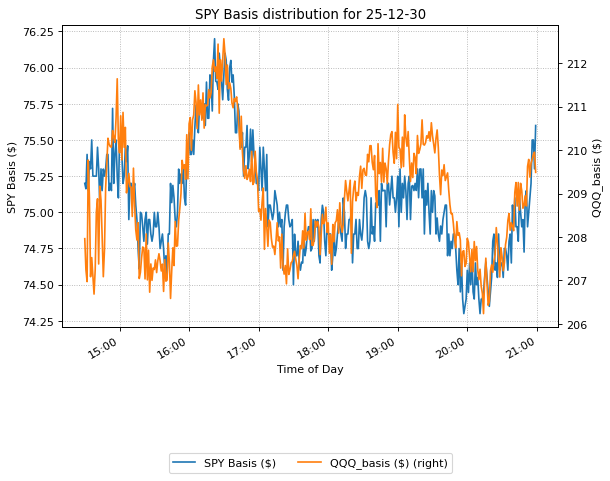

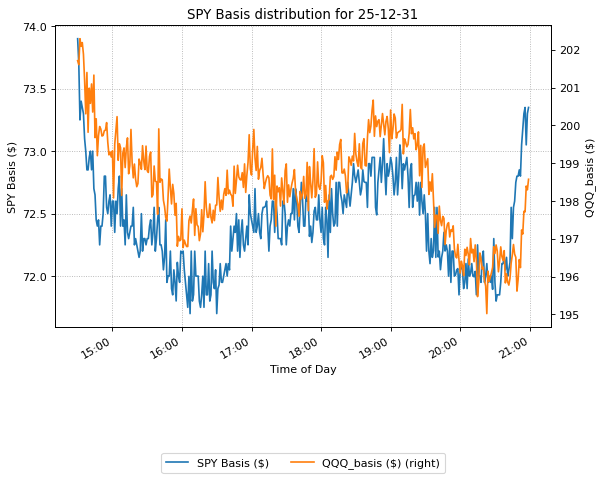

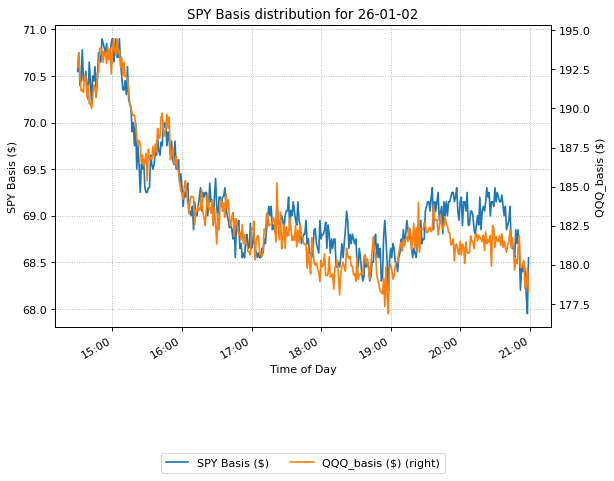

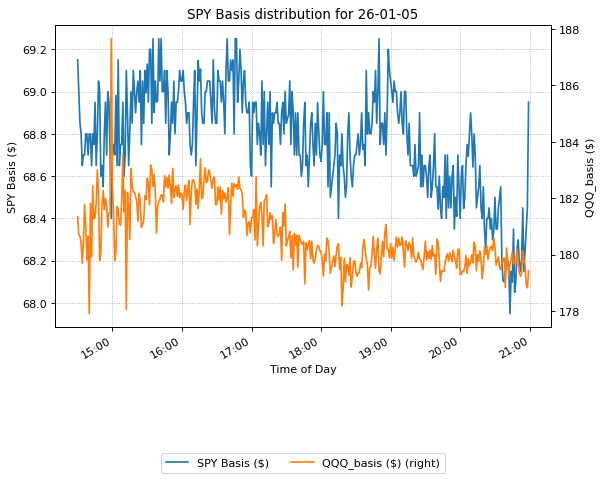

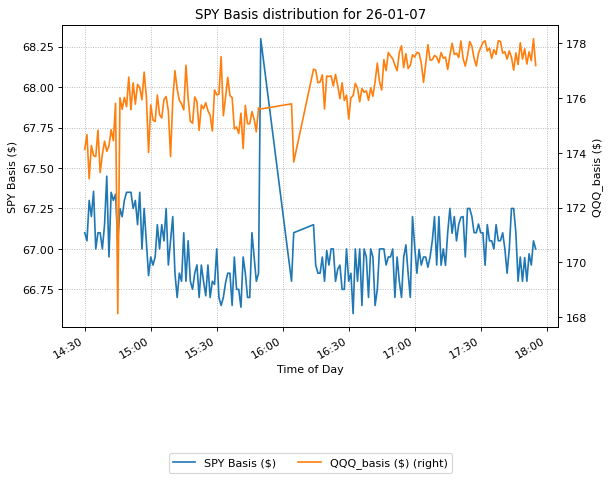

In [100]:
# Let us split up the distribution based on days first
# Then let us plot the SPY_basis and QQQ_basis individually

# To do so we first split them up by day
establish_intraday_basis_df_split_by_day = [group[1] for group in establish_intraday_basis_df.groupby(establish_intraday_basis_df.Datetime.dt.date)]
# establish_intraday_basis_df_split_by_day[1]

myFmt = mdates.DateFormatter('%H:%M') # here we can format our datetick labels as desired


# We need to run a loop to plot for each individual day to get the distribution of SPY_basis and QQQ_basis
for i in establish_intraday_basis_df_split_by_day:
    i['Time_of_Day'] = pd.to_datetime(i['Datetime'])
    i = i.set_index('Time_of_Day')

    fig=plt.figure(figsize=(8, 6), dpi=80)

    
    plt.title(f'SPY Basis distribution for {i[:1].Datetime.dt.strftime('%y-%m-%d').unique()[0]}')

    ax1 = i['SPY_basis'].plot(label ='SPY Basis ($)', x_compat=True)
    
    ax2 = i['QQQ_basis'].plot(secondary_y =True, label = "QQQ_basis ($)", x_compat=True)
    
    ax1.set_ylabel('SPY Basis ($)')
    ax2.set_ylabel('QQQ_basis ($)')
    ax1.set_xlabel('Time of Day')
    
    handles,labels = [],[]
    for ax in fig.axes:
        for h,l in zip(*ax.get_legend_handles_labels()):
            handles.append(h)
            labels.append(l)

    
    plt.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.5), ncol = 3)
    fig.subplots_adjust(bottom = 0.25)
    
    plt.gca().xaxis.set_major_formatter(myFmt)
    
    ax1.grid(True, linestyle = ':')
    # ax2.grid(True, linestyle = ':')
    plt.show()

## 2. **Trade the basis:** for this exercise, you will use the following rules for trade entry and exit for each day of the second half data set
a. Short basis trade:
- i. When futures basis > 1.5 std, short futures and long cash
- ii. When futures basis < 1std, exit the position

b. Long basis trade:
- i. When futures basis < -1.5 std, long futures and short cash
- ii. When futures basis > -1std, exit the position
  
c. Exit the positions at the market close if you have open positions

d. Tally up your daily trading P&L and summarize your trading stats in the following format:

| Description | Stats |
| :--- | :--- |
| Number of days | |
| Average daily trades | |
| Average duration per trade | |
| Average daily P&L | |
| Maximum daily P&L | |
| Minimum daily P&L | |
| Stdev of daily P&L | |

Before we decide on how to go about doing the short basis trade or long basis trade, we need to determine specifically the following:
* 1.5 std for both **SPY** and **QQQ**
* 1 std for both **SPY** and **QQQ**
* Mean basis for both **SPY** and **QQQ**

To generate these `std` values we would need `establish_intraday_basis_df` variable.
To subsequently test the std values we would need to test it on `test_intraday_basis_df` and generate the following:
- Number of days
- Average daily trades
- Average duration per trade
- Average daily P&L
- Maximum daily P&L
- Minimum daily P&L
- Stdev of daily P&L

In [104]:
establish_intraday_basis_df.head()

Ticker,Datetime,ES=F,NQ=F,QQQ,SPY,SPY_basis,QQQ_basis
0,2025-12-30 14:30:00+00:00,6952.50,25717.50,620.429993,687.729980,75.200195,207.962464
1,2025-12-30 14:31:00+00:00,6950.25,25710.00,620.265015,687.508728,75.162720,207.245684
2,2025-12-30 14:32:00+00:00,6951.50,25723.50,620.599976,687.609985,75.400146,206.973464
3,2025-12-30 14:33:00+00:00,6948.25,25720.75,620.465027,687.309998,75.150024,209.772002
4,2025-12-30 14:34:00+00:00,6948.75,25720.50,620.479980,687.340027,75.349731,208.907171


### Compure the necessary `μ` values and `σ` values from `establish_intraday_basis_df`

In [107]:
sd_1_SPY_basis_train_data = establish_intraday_basis_df['SPY_basis'].std()
sd_1_5_SPY_basis_train_data = 1.5 * establish_intraday_basis_df['SPY_basis'].std()
mean_SPY_basis_train_data = establish_intraday_basis_df['SPY_basis'].mean()
min_SPY_basis_train_data = establish_intraday_basis_df['SPY_basis'].min()
max_SPY_basis_train_data = establish_intraday_basis_df['SPY_basis'].max()

sd_1_QQQ_basis_train_data = establish_intraday_basis_df['QQQ_basis'].std()
sd_1_5_QQQ_basis_train_data = 1.5 * establish_intraday_basis_df['QQQ_basis'].std()
mean_QQQ_basis_train_data = establish_intraday_basis_df['QQQ_basis'].mean()
min_QQQ_basis_train_data = establish_intraday_basis_df['QQQ_basis'].min()
max_QQQ_basis_train_data = establish_intraday_basis_df['QQQ_basis'].max()

print(f"""

For SPY:
-> 1 STD of SPY basis: {sd_1_SPY_basis_train_data}
-> 1.5 STD of SPY basis: {sd_1_5_SPY_basis_train_data}
-> Mean of SPY basis: {mean_SPY_basis_train_data}
-> Min of SPY basis: {min_SPY_basis_train_data}
-> Max of SPY basis: {max_SPY_basis_train_data}

-> 1 STD of QQQ: {sd_1_QQQ_basis_train_data}, 
-> 1.5 STD of QQQ: {sd_1_5_QQQ_basis_train_data}
-> Mean of QQQ basis: {mean_QQQ_basis_train_data}
-> Min of QQQ basis: {min_QQQ_basis_train_data}
-> Max of QQQ basis: {max_QQQ_basis_train_data}
""")



For SPY:
-> 1 STD of SPY basis: 2.8082185189269624
-> 1.5 STD of SPY basis: 4.212327778390444
-> Mean of SPY basis: 70.89072711045073
-> Min of SPY basis: 66.5999755859375
-> Max of SPY basis: 76.199951171875

-> 1 STD of QQQ: 12.179051500525894, 
-> 1.5 STD of QQQ: 18.26857725078884
-> Mean of QQQ basis: 191.1496924641591
-> Min of QQQ basis: 168.12044999999853
-> Max of QQQ basis: 212.5675891418432



Ok now that we have successfully calculated the necessary standard deviations we needed. Let us try an envision how our final output would look like as to at which points the trades would occur.

### Visualise our trades

* For this I abmitted I did use GenAI but it was limited to using `ax1` and `ax2` instead of `plt`.
* I also admit that GenAI was used here to make the plot appear nicer by using

```{python}
    ax1.set_ylim(i['SPY_basis'].min() - 0.25, i['SPY_basis'].max() + 0.25)
    ax2.set_ylim(i['QQQ_basis'].min() - 0.25, i['QQQ_basis'].max() + 0.25)
```

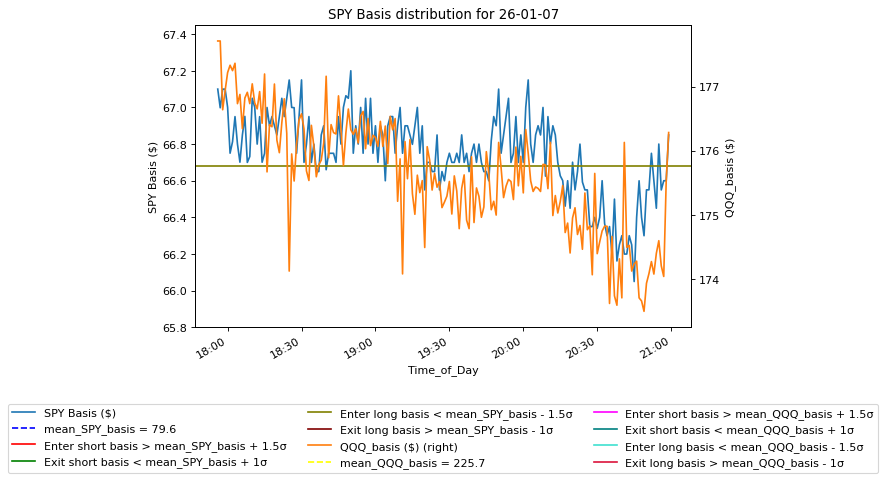

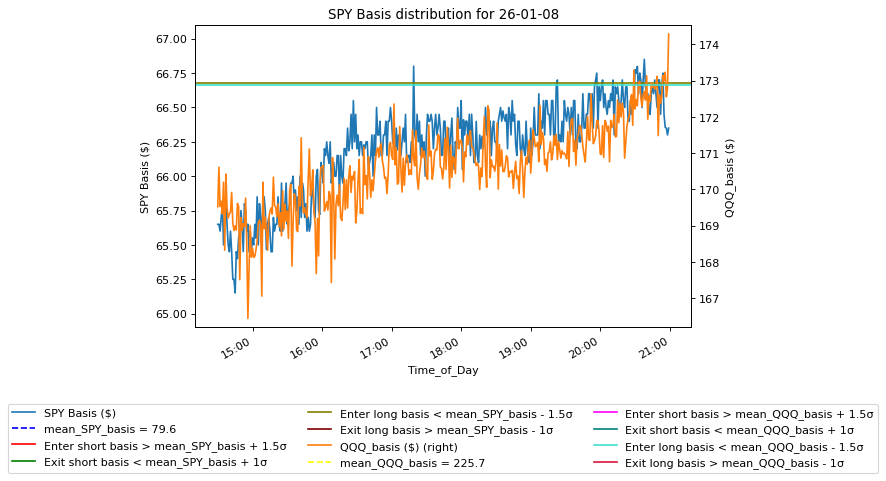

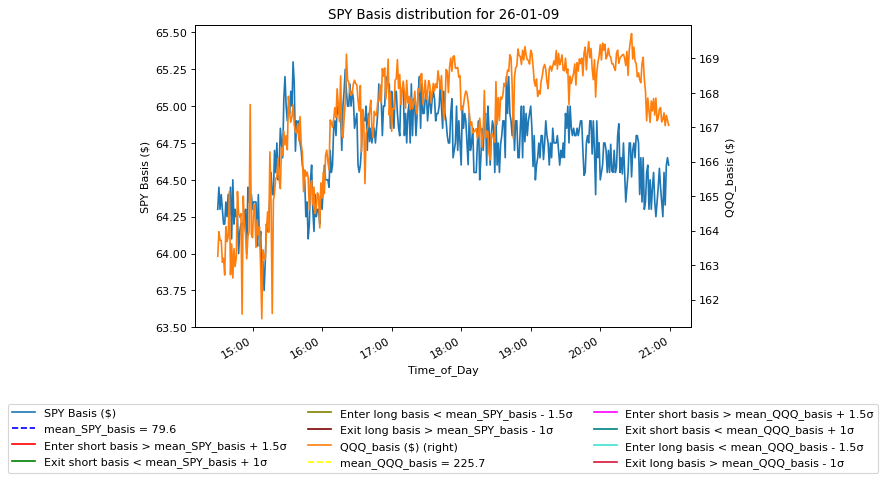

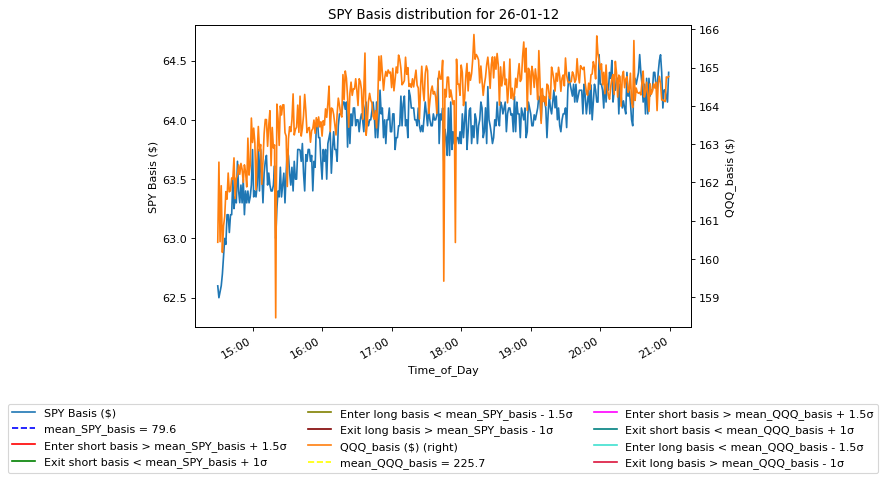

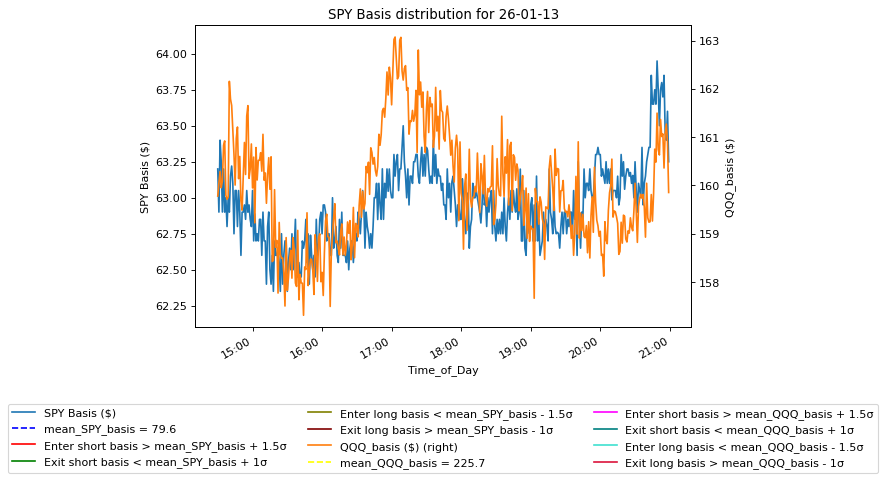

In [112]:
# Let us split up the distribution based on days first
# Then let us plot the SPY_basis and QQQ_basis individually

# To do so we first split them up by day
test_intraday_basis_df_split_by_day = [group[1] for group in test_intraday_basis_df.groupby(test_intraday_basis_df.Datetime.dt.date)]
# establish_intraday_basis_df_split_by_day[1]

myFmt = mdates.DateFormatter('%H:%M') # here we can format our datetick labels as desired


# We need to run a loop to plot for each individual day to get the distribution of SPY_basis and QQQ_basis
for i in test_intraday_basis_df_split_by_day:
    # To ensure we have sufficient data to plot something meaningful:
    if len(i) < 10:
        continue
    
    i['Time_of_Day'] = pd.to_datetime(i['Datetime'])
    i = i.set_index('Time_of_Day')

    fig=plt.figure(figsize=(8, 6), dpi=80)
    # fig=plt.figure(dpi=80)

    
    plt.title(f'SPY Basis distribution for {i[:1].Datetime.dt.strftime('%y-%m-%d').unique()[0]}')

    ax1 = i['SPY_basis'].plot(label ='SPY Basis ($)', x_compat=True)

    ### Originally it was plt instead of ax1 here
    # Plot lines for SPY mean basis as well as 1 std and 1.5 std away from the basis
    ax1.axhline(y=mean_SPY_basis_train_data, color='blue', linestyle='--', label='mean_SPY_basis = 79.6')

    # SPY Short basis trade 
    # To enter short basis
    ax1.axhline(y=mean_SPY_basis_train_data+sd_1_5_SPY_basis_train_data, color='red', linestyle='-', label='Enter short basis > mean_SPY_basis + 1.5\u03C3')
    # To leave short basis
    ax1.axhline(y=mean_SPY_basis_train_data+sd_1_SPY_basis_train_data, color='green', linestyle='-', label='Exit short basis < mean_SPY_basis + 1\u03C3')

    # SPY Long basis trade 
    # To enter Long basis
    ax1.axhline(y=mean_SPY_basis_train_data-sd_1_5_SPY_basis_train_data, color='olive', linestyle='-', label='Enter long basis < mean_SPY_basis - 1.5\u03C3')
    # To leave Long basis
    ax1.axhline(y=mean_SPY_basis_train_data-sd_1_SPY_basis_train_data, color='maroon', linestyle='-', label='Exit long basis > mean_SPY_basis - 1\u03C3')
    ### ---------------------
    
    ax1.set_ylabel('SPY Basis ($)')
    ax1.set_xlabel('Time of Day')

    
    ax2 = i['QQQ_basis'].plot(secondary_y =True, label = "QQQ_basis ($)", x_compat=True)

    ### Originally it was plt instead of ax2 here
    # Plot lines for QQQ mean basis as well as 1 std and 1.5 std away from the basis
    ax2.axhline(y=mean_QQQ_basis_train_data, color='yellow', linestyle='--', label='mean_QQQ_basis = 225.7')

    # QQQ Short basis trade 
    # To enter short basis
    ax2.axhline(y=mean_QQQ_basis_train_data+sd_1_5_QQQ_basis_train_data, color='magenta', linestyle='-', label='Enter short basis > mean_QQQ_basis + 1.5\u03C3')
    # To leave short basis
    ax2.axhline(y=mean_QQQ_basis_train_data+sd_1_QQQ_basis_train_data, color='teal', linestyle='-', label='Exit short basis < mean_QQQ_basis + 1\u03C3')

    # QQQ Long basis trade 
    # To enter Long basis
    ax2.axhline(y=mean_QQQ_basis_train_data-sd_1_5_QQQ_basis_train_data, color='turquoise', linestyle='-', label='Enter long basis < mean_QQQ_basis - 1.5\u03C3')
    # To leave Long basis
    ax2.axhline(y=mean_QQQ_basis_train_data-sd_1_QQQ_basis_train_data, color='crimson', linestyle='-', label='Exit long basis > mean_QQQ_basis - 1\u03C3')
    ### ---------------------
    ax2.set_ylabel('QQQ_basis ($)')
    
    
    handles,labels = [],[]
    for ax in fig.axes:
        for h,l in zip(*ax.get_legend_handles_labels()):
            handles.append(h)
            labels.append(l)

    # Force the limits to match the daily data, cutting off the historical lines if they are too far away
    ax1.set_ylim(i['SPY_basis'].min() - 0.25, i['SPY_basis'].max() + 0.25)
    ax2.set_ylim(i['QQQ_basis'].min() - 0.25, i['QQQ_basis'].max() + 0.25)

    plt.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.5), ncol = 3)
    fig.subplots_adjust(bottom = 0.25)
    
    plt.gca().xaxis.set_major_formatter(myFmt)
    
    # ax1.grid(True, linestyle = ':')
    # ax2.grid(True, linestyle = ':')
    plt.show()

In [113]:
test_intraday_basis_df_split_by_day[0]

Ticker,Datetime,ES=F,NQ=F,QQQ,SPY,SPY_basis,QQQ_basis,Time_of_Day
1743,2026-01-07 17:56:00+00:00,6997.00,25967.25,627.239990,692.989990,67.100098,177.713286,2026-01-07 17:56:00+00:00
1744,2026-01-07 17:57:00+00:00,6997.00,25967.25,627.239990,693.000183,66.998169,177.713286,2026-01-07 17:57:00+00:00
1745,2026-01-07 17:58:00+00:00,6996.50,25967.00,627.260010,692.940002,67.099976,176.640164,2026-01-07 17:58:00+00:00
1746,2026-01-07 17:59:00+00:00,6997.00,25971.00,627.349976,692.989990,67.100098,176.941139,2026-01-07 17:59:00+00:00
1747,2026-01-07 18:00:00+00:00,6995.00,25964.25,627.179016,692.799927,67.000732,177.220291,2026-01-07 18:00:00+00:00
...,...,...,...,...,...,...,...,...
1922,2026-01-07 20:55:00+00:00,6961.50,25824.75,623.849976,689.469971,66.800293,174.596789,2026-01-07 20:55:00+00:00
1923,2026-01-07 20:56:00+00:00,6961.75,25825.00,623.865601,689.520020,66.549805,174.204353,2026-01-07 20:56:00+00:00
1924,2026-01-07 20:57:00+00:00,6962.25,25826.25,623.900024,689.565002,66.599976,174.038986,2026-01-07 20:57:00+00:00
1925,2026-01-07 20:58:00+00:00,6962.00,25826.50,623.869995,689.539978,66.600220,175.523668,2026-01-07 20:58:00+00:00


As the date of 2025-12-12 has only 1 time we shall ignore this altogether

**Learning point:** 
* We do not expect lots of liquidity from either SPY/QQQ futures. Especially considering the high market volatility observed on 16 December and 17 Deecember.
* On the days of 17 December 2025. We observe abnormal spikes in the datapoints for the distributions of both SPY and QQQ Equities.  This might be because markets become [mixed After Fed Rate Cut](https://westwoodgroup.com/weeklyblog/basis-points-december-16-2025/#:~:text=Wall%20Street%20experienced%20a%20mixed,materials%20and%20small%2Dcap%20stocks.).


___
It doesn't make sense to sum up the trading stats for SPY/QQQ. So we should tabulate the results for SPY and QQQ into 2 separate tables.

We need to create functions to execute the following:

a. Short basis trade:
- i. When futures basis > 1.5 std, short futures and long cash
- ii. When futures basis < 1std, exit the position

b. Long basis trade:
- i. When futures basis < -1.5 std, long futures and short cash
- ii. When futures basis > -1std, exit the position

c. Exit the positions at the market close if you have open positions

d. Tally up your daily trading P&L and summarize your trading stats in the following format:

| Description | Stats |
| :--- | :--- |
| Number of days | |
| Average daily trades | |
| Average duration per trade | |
| Average daily P&L | |
| Maximum daily P&L | |
| Minimum daily P&L | |
| Stdev of daily P&L | |

### Pseudo-code for overall function

In [120]:
# We need a helper function for the following:
# Short basis trade (entry/exit, SPY/QQQ, SPY value/QQQ value, ES=F value/NQ=F value, time)
    # Input: 
        # "SPY" or "QQQ" -> string datatype
        # "Entry" or "Exit" -> string
        # SPY value/QQQ value -> Float
        # ES=F value/NQ=F value -> Float
        # Time

    # Conditional: 
        # Check "SPY" or "QQQ"
        # Check for entry or exit

    # Entry short basis signals: 
        # Futures basis > mean + 1.5 std -> Short futures & Long Cash -> P&L. Question to self: How exactly is P&L computed
            # P&L = (index_futures_position - corresponding_ETF_position)
            # Append the P&L to list
            # Append the time to list
            # Set: 
                # corresponding_ETF_position += index_futures_position
                # index_futures_position = 0
                # short_basis_position_active boolean to True
                # No_of_etfs = corresponding_ETF_position/ (SPY value/QQQ value)
                # No_of_futures = 0
                # Total_no_of_trades += 1

    # Exit short basis signals: 
        # Futures basis < mean + 1 std -> Exit (Long futures & Short Cash) -> P&L. Question to self: How exactly is P&L computed
            # P&L = (corresponding_ETF_position - index_futures_position)
            # Append the P&L to list
            # Append the time to list
            # Set:
                # index_futures_position += corresponding_ETF_position
                # corresponding_ETF_position = 0
                # short_basis_position_active boolean to False
                # No_of_etfs = 0
                # No_of_futures = index_futures_position/ (ES=F value/NQ=F value)
                # Total_no_of_trades += 1

# Long basis trade (entry/exit, SPY/QQQ, SPY value/QQQ value, ES=F value/NQ=F value, time):
    # Input: 
        # "SPY" or "QQQ" -> string datatype
        # "Entry" or "Exit" -> string
        # SPY value/QQQ value -> Float
        # ES=F value/NQ=F value -> Float

    # Conditional: 
        # Check "SPY" or "QQQ"
        # Check for entry or exit

    # Entry long basis signals: 
        # Futures basis < mean - 1.5 std -> Long futures & Short Cash -> P&L. Question to self: How exactly is P&L computed
            # P&L = (corresponding_ETF_position - index_futures_position)
            # Append the P&L to list
            # Append the time to list
            # Set:
                # index_futures_position += corresponding_ETF_position
                # corresponding_ETF_position = 0
                # long_basis_position_active = True
                # No_of_etfs = 0
                # No_of_futures = index_futures_position/ (ES=F value/NQ=F value)
                # Total_no_of_trades += 1

    # Exit long basis signals: 
        # Futures basis > mean - 1 std -> Exit (Short futures & Long Cash) -> P&L. Question to self: How exactly is P&L computed
            # P&L = (index_futures_position - corresponding_ETF_position)
            # Append the P&L to list
            # Append the time to list
            # Set:
                # corresponding_ETF_position += index_futures_position
                # index_futures_position = 0                     
                # long_basis_position_active boolean to False
                # No_of_etfs = corresponding_ETF_position/ (SPY value/QQQ value)
                # No_of_futures = 0
                # Total_no_of_trades += 1

# --------------------Main function---------------------
# Input: "SPY" or "QQQ" string datatype


# -------Initialize---------
# No_of_etfs = corresponding_ETF_position/[first value of SPY/QQQ in test_intraday_basis_df]
# No_of_futures = index_futures_position/[first value of ES=F/NQ=F in test_intraday_basis_df]
# index_futures_position = 1_000_000
# corresponding_ETF_position = 1_000_000
# Total_no_of_trades = 0

# Boolean initialised to False to check:
    # short_basis_position_active = False
    # long_basis_position_active = False

# We need a list datastructure to append the P&L
# List datastructure to account for when trade takes place
# --------------------------


# Loop through every row in per day from test_intraday_basis_df_split_by_day
# --------------- LOOP --------------------
    # -------Typical Updates---------
    # Continuously updated the index_futures_position and corresponding_ETF_position to be scaled in accordance to the futures and ETFs values
    # index_futures_position = No_of_etfs * SPY/QQQ value for that row
    # corresponding_ETF_position = No_of_futures * ES=F/NQ=F value for that row
    # -------------------------------

    # --------Conditional Checks -------------
    # Futures basis > mean + 1.5 std && long_basis_position_active = False && long_basis_position_active = False:
        # Trigger Entry for short basis

    # Futures basis < mean + 1 std && long_basis_position_active = True && long_basis_position_active = False:
        # Trigger Exit short basis

    # Futures basis < mean - 1.5 std && long_basis_position_active = False && long_basis_position_active = False:
        # Trigger Entry long basis
    # Futures basis > mean - 1 std && long_basis_position_active = False && long_basis_position_active = True:
        # Trigger Exist long basis
    # Else:
        # Continue
# ------------END LOOP --------------------    

# Operations to get output: 
    # No of days
    # Average daily trades
    # Average duration per trade
    # Average daily P&L, 
    # Maximum daily P&L
    # Minimum daily P&L
    # Stdev of daily P&L

# No of days = We can easily track the number of days based on length of test_intraday_basis_df_split_by_day
# Average daily trades = Total_no_of_trades / No of days
# Average duration per trade = (might have to us a loop to calculate the time intervals maybe in hours and minutes format)
# Average daily P&L

### Actual-code for overall function

**Recap**: Our distribution for `establish_intraday_basis_df`

In [124]:
print(f"""
For SPY:
-> 1 STD of SPY basis: {sd_1_SPY_basis_train_data}
-> 1.5 STD of SPY basis: {sd_1_5_SPY_basis_train_data}
-> Mean of SPY basis: {mean_SPY_basis_train_data}
-> Min of SPY basis: {min_SPY_basis_train_data}
-> Max of SPY basis: {max_SPY_basis_train_data}

-> 1 STD of QQQ: {sd_1_QQQ_basis_train_data}, 
-> 1.5 STD of QQQ: {sd_1_5_QQQ_basis_train_data}
-> Mean of QQQ basis: {mean_QQQ_basis_train_data}
-> Min of QQQ basis: {min_QQQ_basis_train_data}
-> Max of QQQ basis: {max_QQQ_basis_train_data}
""")


For SPY:
-> 1 STD of SPY basis: 2.8082185189269624
-> 1.5 STD of SPY basis: 4.212327778390444
-> Mean of SPY basis: 70.89072711045073
-> Min of SPY basis: 66.5999755859375
-> Max of SPY basis: 76.199951171875

-> 1 STD of QQQ: 12.179051500525894, 
-> 1.5 STD of QQQ: 18.26857725078884
-> Mean of QQQ basis: 191.1496924641591
-> Min of QQQ basis: 168.12044999999853
-> Max of QQQ basis: 212.5675891418432



Our actual distribution for `test_intraday_basis_df`

In [127]:
mean_SPY_basis_test_data = test_intraday_basis_df['SPY_basis'].mean()
min_SPY_basis_test_data = test_intraday_basis_df['SPY_basis'].min()
max_SPY_basis_test_data = test_intraday_basis_df['SPY_basis'].max()


mean_QQQ_basis_test_data = test_intraday_basis_df['QQQ_basis'].mean()
min_QQQ_basis_test_data = test_intraday_basis_df['QQQ_basis'].min()
max_QQQ_basis_test_data = test_intraday_basis_df['QQQ_basis'].max()

print(f"""
For SPY:
-> Mean of SPY basis: {mean_SPY_basis_test_data}
-> Min of SPY basis: {min_SPY_basis_test_data}
-> Max of SPY basis: {max_SPY_basis_test_data}

-> Mean of QQQ basis: {mean_QQQ_basis_test_data}
-> Min of QQQ basis: {min_QQQ_basis_test_data}
-> Max of QQQ basis: {max_QQQ_basis_test_data}
""")


For SPY:
-> Mean of SPY basis: 64.6875957524011
-> Min of SPY basis: 62.3499755859375
-> Max of SPY basis: 67.2001953125

-> Mean of QQQ basis: 166.57930845778017
-> Min of QQQ basis: 157.30684433593706
-> Max of QQQ basis: 177.71328552245905



#### **Test out whether our loop works**

Now let us create operations to test out whether the trigger for when to enter or exit for a long basis and short basis works.

In [131]:
ETF_for_index_arbitrage = "SPY" # Option here are: SPY and "QQQ"

corresponding_ETF_position = 1_000_000
index_futures_position = 1_000_000

No_of_etfs = corresponding_ETF_position/test_intraday_basis_df[ETF_for_index_arbitrage].values[0]
No_of_futures = index_futures_position/ test_intraday_basis_df[ETF_for_index_arbitrage].values[0]
Total_no_of_trades = 0

# Set to none at first
futures_to_look_at = None
futures_basis_to_look_at = None
position = None

# Boolean initialised to False to check:
short_basis_position_active = False
long_basis_position_active = False

# List to store the P&L and timestamps of trades which would later be used for analysis
PnL_list = []
time_stamps_of_trade_occurence = []


# Generate signals for the following cases
if ETF_for_index_arbitrage == "SPY":
    enter_short_basis_trade_signal = mean_SPY_basis_train_data + sd_1_5_SPY_basis_train_data
    exit_short_basis_trade_signal = mean_SPY_basis_train_data + sd_1_SPY_basis_train_data
    enter_long_basis_trade_signal = mean_SPY_basis_train_data - sd_1_5_SPY_basis_train_data
    exit_long_basis_trade_signal = mean_SPY_basis_train_data - sd_1_SPY_basis_train_data
    futures_to_look_at = "ES=F"
    futures_basis_to_look_at = "SPY_basis"
    
    # print("SPY activated")

elif ETF_for_index_arbitrage == "QQQ":
    enter_short_basis_trade_signal = mean_QQQ_basis_train_data + sd_1_5_QQQ_basis_train_data
    exit_short_basis_trade_signal = mean_QQQ_basis_train_data + sd_1_QQQ_basis_train_data
    enter_long_basis_trade_signal = mean_QQQ_basis_train_data - sd_1_5_QQQ_basis_train_data
    exit_long_basis_trade_signal = mean_QQQ_basis_train_data - sd_1_QQQ_basis_train_data
    futures_to_look_at = "NQ=F"
    futures_basis_to_look_at = "QQQ_basis"
    # print("QQQ activated")

for index, row in test_intraday_basis_df.iterrows():
    
    futures_basis_price = row[futures_basis_to_look_at]

    # print(f"""
    # Futures Basis Price: {futures_basis_price}
    
    # enter_short_basis_trade_signal: {enter_short_basis_trade_signal}
    # exit_short_basis_trade_signal: {exit_short_basis_trade_signal}
    # enter_long_basis_trade_signal: {enter_long_basis_trade_signal}
    # exit_long_basis_trade_signal: {exit_long_basis_trade_signal}
    # """)

    # Short Basis Trade Exit
    if futures_basis_price < exit_short_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == True:
        position = "Exit"
        short_basis_position_active = False
        # print("Exit Short Basis Trade")

    # Long Basis Trade Exit
    if futures_basis_price > exit_long_basis_trade_signal and long_basis_position_active == True and short_basis_position_active == False:
        position = "Exit"
        long_basis_position_active = False
        # print("Exit Long Basis Trade")

    # Short Basis Trade Entry
    if futures_basis_price > enter_short_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == False:
        position = "Enter"
        short_basis_position_active = True
        # print("Enter Short Basis Trade")
        
    # Long Basis Trade Entry
    if futures_basis_price < enter_long_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == False:
        position = "Enter"
        long_basis_position_active = True
        # print("Enter Long Basis Trade")

    # Nothing happens
    else: 
        # print("No trades happen")
        continue

#### **Go and implement our helper functions**

Now that we have successfully triggured when the entry and exit positions for a long and short basis works. Let's create the helper function for the short basis trade.

In [134]:
def short_basis_trade(position, 
                      timestamp):
    PnL_calculate = 0

    global PnL_list, PnL_for_the_day
    global time_stamps_of_trade_entry_occurence, time_stamps_of_trade_exit_occurence
    global index_futures_position_in_trade, index_futures_position_before_entry
    global No_of_etfs_in_trade, No_of_etfs_before_entry
    global corresponding_ETF_position_in_trade, corresponding_ETF_position_before_entry
    global index_futures_value_in_trade, index_futures_value_before_entry
    global corresponding_ETF_value_in_trade, corresponding_ETF_value_before_entry
    global No_of_futures_in_trade, No_of_futures_before_entry
    global Total_no_of_trades


    # Account for the case of short basis entry position
    if position == "Entry":
        # print("short basis entry triggered")
        time_stamps_of_trade_entry_occurence.append(timestamp)
        # short futures and long cash
        
        # To store the values right before entry
        index_futures_position_before_entry = index_futures_position_in_trade
        No_of_etfs_before_entry = No_of_etfs_in_trade
        corresponding_ETF_position_before_entry = corresponding_ETF_position_in_trade
        index_futures_value_before_entry = index_futures_value_in_trade
        corresponding_ETF_value_before_entry = corresponding_ETF_value_in_trade
        No_of_futures_before_entry = No_of_futures_in_trade

        # short futures and long cash
        # To update the values based on shorting the futures and longing the cash
        corresponding_ETF_position_in_trade += index_futures_position_before_entry
        No_of_etfs_in_trade = corresponding_ETF_position_in_trade/corresponding_ETF_value_in_trade
        index_futures_position_in_trade = 0
        No_of_futures_in_trade = 0
        
        
    # Account for the case of short basis exit position
    elif position == "Exit":   
        # print("short basis exit triggered")
        # print(f"""
        #         corresponding_ETF_position_before_entry: {corresponding_ETF_position_before_entry}
        #         index_futures_position_before_entry: {index_futures_position_before_entry}
        # """)

        time_stamps_of_trade_exit_occurence.append(timestamp)        
        Total_no_of_trades += 1 
        
        # To update as we long futures and short cash
        index_futures_position_in_trade = No_of_futures_before_entry * index_futures_value_in_trade
        No_of_futures_in_trade = No_of_futures_before_entry
        corresponding_ETF_position_in_trade -= index_futures_position_in_trade
        No_of_etfs_in_trade = corresponding_ETF_position_in_trade/corresponding_ETF_value_in_trade

        # print(f"""
        #         corresponding_ETF_position_in_trade: {corresponding_ETF_position_in_trade}
        #         index_futures_position_in_trade: {index_futures_position_in_trade}
        # """)
        # ------------------
        
        PnL_calculate = corresponding_ETF_position_in_trade + index_futures_position_in_trade - corresponding_ETF_position_before_entry - index_futures_position_before_entry
        PnL_for_the_day += PnL_calculate
        PnL_list.append(PnL_calculate)
        # print(f"P&L for this trade is: {PnL_calculate}")
    
    else:
        print("Something is wrong")

Let's create the helper function for the long basis trade.

In [137]:
def long_basis_trade(position, 
                      timestamp):
    PnL_calculate = 0

    global PnL_list, PnL_for_the_day
    global time_stamps_of_trade_entry_occurence, time_stamps_of_trade_exit_occurence
    global index_futures_position_in_trade, index_futures_position_before_entry
    global No_of_etfs_in_trade, No_of_etfs_before_entry
    global corresponding_ETF_position_in_trade, corresponding_ETF_position_before_entry
    global index_futures_value_in_trade, index_futures_value_before_entry
    global corresponding_ETF_value_in_trade, corresponding_ETF_value_before_entry
    global No_of_futures_in_trade, No_of_futures_before_entry
    global Total_no_of_trades

    # Account for the case of long basis entry position
    if position == "Entry":
        # print("long basis entry triggered")
        time_stamps_of_trade_entry_occurence.append(timestamp)
        # long futures and short cash

        # To store the values right before entry
        index_futures_position_before_entry = index_futures_position_in_trade
        No_of_etfs_before_entry = No_of_etfs_in_trade
        corresponding_ETF_position_before_entry = corresponding_ETF_position_in_trade
        index_futures_value_before_entry = index_futures_value_in_trade
        corresponding_ETF_value_before_entry = corresponding_ETF_value_in_trade
        No_of_futures_before_entry = No_of_futures_in_trade

        # long futures and short cash
        # To update the values based on longing the futures and shorting the cash
        index_futures_position_in_trade += corresponding_ETF_position_in_trade
        No_of_futures_in_trade = index_futures_position_in_trade/index_futures_value_in_trade
        corresponding_ETF_position_in_trade = 0
        No_of_etfs_in_trade = 0



    # Account for the case of long basis exit position
    # short futures and long cash
    elif position == "Exit":

        # print("long basis exit triggered")
        # print(f"""
        #         corresponding_ETF_position_before_entry: {corresponding_ETF_position_before_entry}
        #         index_futures_position_before_entry: {index_futures_position_before_entry}
        # """)
        time_stamps_of_trade_exit_occurence.append(timestamp)        
        Total_no_of_trades += 1 
        
        # To update as we short futures and long cash
        corresponding_ETF_position_in_trade = No_of_etfs_before_entry * corresponding_ETF_value_in_trade
        No_of_etfs_in_trade = No_of_etfs_before_entry
        index_futures_position_in_trade -= corresponding_ETF_position_in_trade
        No_of_futures_in_trade = index_futures_position_in_trade/index_futures_value_in_trade  

        # print(f"""
        #         corresponding_ETF_position_in_trade: {corresponding_ETF_position_in_trade}
        #         index_futures_position_in_trade: {index_futures_position_in_trade}
        # """)
        # ------------------
        PnL_calculate = corresponding_ETF_position_in_trade + index_futures_position_in_trade - corresponding_ETF_position_before_entry - index_futures_position_before_entry
        PnL_for_the_day += PnL_calculate
        PnL_list.append(PnL_calculate)
        # print(f"P&L for this trade is: {PnL_calculate}")

    else:
        print("Something is wrong")

Now let us try testing our helper functions by adding it in.

In [140]:
ETF_for_index_arbitrage = "SPY" # Option here are: SPY and "QQQ"

# Set to none at first
futures_to_look_at = None
futures_basis_to_look_at = None
position = None

# Generate signals for the following cases
if ETF_for_index_arbitrage == "SPY":
    enter_short_basis_trade_signal = mean_SPY_basis_train_data + sd_1_5_SPY_basis_train_data
    exit_short_basis_trade_signal = mean_SPY_basis_train_data + sd_1_SPY_basis_train_data
    enter_long_basis_trade_signal = mean_SPY_basis_train_data - sd_1_5_SPY_basis_train_data
    exit_long_basis_trade_signal = mean_SPY_basis_train_data - sd_1_SPY_basis_train_data
    futures_to_look_at = "ES=F"
    futures_basis_to_look_at = "SPY_basis"
    
elif ETF_for_index_arbitrage == "QQQ":
    enter_short_basis_trade_signal = mean_QQQ_basis_train_data + sd_1_5_QQQ_basis_train_data
    exit_short_basis_trade_signal = mean_QQQ_basis_train_data + sd_1_QQQ_basis_train_data
    enter_long_basis_trade_signal = mean_QQQ_basis_train_data - sd_1_5_QQQ_basis_train_data
    exit_long_basis_trade_signal = mean_QQQ_basis_train_data - sd_1_QQQ_basis_train_data
    futures_to_look_at = "NQ=F"
    futures_basis_to_look_at = "QQQ_basis"

# Boolean initialised to False to check:
short_basis_position_active = False
long_basis_position_active = False

# List to store the P&L, timestamps of entry trades, and timestampes of exit trades which would later be used for analysis
PnL_list = []
# To store entry occurences
time_stamps_of_trade_entry_occurence = []
# To store exit occurences
time_stamps_of_trade_exit_occurence = []
# To store the PnL per day
PnL_per_day = []

# Need to figure out how to incorporate the number of ETFs and number of futures right before entering long and short basis positions

# We need to keep track of the number of ETFs and futures before we enter the trade
# This would be useful in computing the P&L
No_of_etfs_before_entry = 0
No_of_futures_before_entry = 0
index_futures_position_before_entry = 0
index_futures_value_before_entry = 0
corresponding_ETF_position_before_entry = 0
corresponding_ETF_value_before_entry = 0


# We also need to keep track of the number of futures while we are in the trade
No_of_etfs_in_trade = corresponding_ETF_position/test_intraday_basis_df[ETF_for_index_arbitrage].values[0]
No_of_futures_in_trade = index_futures_position/ test_intraday_basis_df[futures_to_look_at].values[0]
index_futures_position_in_trade = 1_000_000
index_futures_value_in_trade = 0
corresponding_ETF_position_in_trade = 1_000_000
corresponding_ETF_value_in_trade = 0

Total_no_of_trades = 0

for individual_day in test_intraday_basis_df_split_by_day:
    PnL_for_the_day = 0
    
    for index, row in individual_day.iterrows():
        index_futures_value_in_trade = row[futures_to_look_at]
        corresponding_ETF_value_in_trade = row[ETF_for_index_arbitrage]
    
        # print(f"""
        #     corresponding_ETF_position: {corresponding_ETF_position_in_trade}, 
        #     index_futures_position: {index_futures_position_in_trade}
        # """)
        
        # corresponding_ETF_position = No_of_etfs_in_trade * ES=F/NQ=F value for that row
        corresponding_ETF_position_in_trade = No_of_etfs_in_trade * corresponding_ETF_value_in_trade
        # index_futures_position = No_of_futures_in_trade  * SPY/QQQ value for that row
        index_futures_position_in_trade = No_of_futures_in_trade * row[futures_to_look_at] 
        
        futures_basis_price = row[futures_basis_to_look_at]
        time_of_occurence = row["Datetime"]
        
        
        # Short Basis Trade Exit
        if futures_basis_price < exit_short_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == True:
            position = "Exit"
            short_basis_position_active = False
            short_basis_trade(position=position, 
                              timestamp=time_of_occurence)
        
        # Long Basis Trade Exit
        if futures_basis_price > exit_long_basis_trade_signal and long_basis_position_active == True and short_basis_position_active == False:
            position = "Exit"
            long_basis_position_active = False
            long_basis_trade(position=position, 
                             timestamp=time_of_occurence)
        
        # Short Basis Trade Entry
        if futures_basis_price > enter_short_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == False:
            position = "Entry"
            short_basis_position_active = True
            short_basis_trade(position=position, 
                              timestamp=time_of_occurence)
            
        # Long Basis Trade Entry
        if futures_basis_price < enter_long_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == False:
            position = "Entry"
            long_basis_position_active = True
            long_basis_trade(position=position, 
                             timestamp=time_of_occurence)
    
    
        # print(row["Datetime"] == test_intraday_basis_df[:1]["Datetime"].item())
        
        # Exit the long basis position at the market close if you have open positions
        if row["Datetime"] == individual_day[-1:]["Datetime"].item() and long_basis_position_active == True:
            print("Final long basis activated")
            position = "Exit"
            long_basis_position_active = False
            long_basis_trade(position=position, 
                             timestamp=time_of_occurence)
            # print(f"""
            # corresponding_ETF_position: {corresponding_ETF_position_in_trade}, 
            # index_futures_position: {index_futures_position_in_trade}
            # """)
        
        # Exit the short basis position at the market close if you have open positions
        elif row["Datetime"] == individual_day[-1:]["Datetime"].item() and short_basis_position_active == True:
            print("Final short basis activated")
            position = "Exit"
            short_basis_position_active = False
            short_basis_trade(position=position, 
                              timestamp=time_of_occurence)
            # print(f"""
            # corresponding_ETF_position: {corresponding_ETF_position_in_trade}, 
            # index_futures_position: {index_futures_position_in_trade}
            # """)
        # Nothing happens
        else:       
            continue
    PnL_per_day.append(PnL_for_the_day)

Final long basis activated
Final long basis activated
Final long basis activated
Final long basis activated
Final long basis activated


**Is this alright?**

Yes it is. Value can increase due to other factors like appreciation/depreciation not entire due to trades
- The very first position of the total sum of corresponding_ETF + index_futures_position = 2,000,000
- The very last position of the total sum of corresponding_ETF + index_futures_position = 2,706,464.3454080285

The code below of 
```{python}
sum(PnL_list)
```
Gives us **702444.6772368597**.

In [143]:
sum(PnL_list)

8793.532008301932

In [145]:
PnL_list[:5]

[-8003.6553887183545,
 2144.0088203381747,
 9149.20282569388,
 11437.941193128587,
 -5933.965442140354]

In [147]:
# time_stamps_of_trade_entry_occurence

In [149]:
len(PnL_list)

5

Looks like both the timestamps match in length which is good.

In [152]:
print(len(time_stamps_of_trade_entry_occurence))
print(len(time_stamps_of_trade_exit_occurence))

5
5


#### **Go and output the necessary results of**


| Description | Stats |
| :--- | :--- |
| Number of days | |
| Average daily trades | |
| Average duration per trade | |
| Average daily P&L | |
| Maximum daily P&L | |
| Minimum daily P&L | |
| Stdev of daily P&L | |

Getting the `Number of days` and `Average daily trades`

In [156]:
No_of_days = len(test_intraday_basis_df_split_by_day)
Avg_daily_trades = round(len(PnL_list)/No_of_days,2)

print(f"""
No_of_days: {No_of_days}
Avg_daily_trades: {Avg_daily_trades}
""")


No_of_days: 5
Avg_daily_trades: 1.0



Getting the `Average duration per trade`

In [159]:
time_diff = []
index = 0
while index < len(time_stamps_of_trade_exit_occurence):
    time_diff.append(time_stamps_of_trade_exit_occurence[index]-time_stamps_of_trade_entry_occurence[index])
    index += 1

average_duration_per_trade=pd.to_timedelta(pd.Series(time_diff)).mean()
print(average_duration_per_trade)


totalMinute, second = divmod(average_duration_per_trade.seconds, 60)
hour, minute = divmod(totalMinute, 60)
print(f"Average duration per trade is: {hour}hours {minute:02}minutes {second:02}seconds")
avg_trade_duration = f"{hour}hours {minute:02}minutes {second:02}seconds"

0 days 05:39:48
Average duration per trade is: 5hours 39minutes 48seconds


Getting the `Average daily P&L`

In [162]:
Average_daily_PnL =round(sum(PnL_list)/No_of_days,2)
Average_daily_PnL

1758.71

Getting the `Maximum daily P&L`

In [165]:
maximum_daily_PnL = round(max(PnL_per_day),2)
maximum_daily_PnL

11437.94

Getting the `Minimum daily P&L`

In [168]:
minimum_daily_PnL = round(min(PnL_per_day),2)
minimum_daily_PnL

-8003.66

Getting the `Stdev of daily P&L`

In [171]:
stdev_daily_PnL = round(st.pstdev(PnL_per_day),2)
stdev_daily_PnL

7783.78

### Arrange neatly in dataframe

In [174]:
# Create a dataframe
properly_formatted = pd.DataFrame({
  'Description': ['Number of days', 'Average daily trades', 'Average duration per trade', 'Average daily P&L', 
                 'Maximum daily P&L', 'Minimum daily P&L', 'Stdev of daily P&L'],
  'Stats': [No_of_days, Avg_daily_trades, avg_trade_duration, 
            Average_daily_PnL, maximum_daily_PnL, minimum_daily_PnL, stdev_daily_PnL],
})
display(properly_formatted)

,Description,Stats
0,Number of days,5
1,Average daily trades,1.0
2,Average duration per trade,5hours 39minutes 48seconds
3,Average daily P&L,1758.71
4,Maximum daily P&L,11437.94
5,Minimum daily P&L,-8003.66
6,Stdev of daily P&L,7783.78


### Let us functionize everything now that it works as we intended

In [177]:
def tally_up_daily_PNL_and_trading_stats(ETF_for_index_arbitrage="SPY",
                                         test_intraday_basis_df_split_by_day=test_intraday_basis_df_split_by_day, 
                                         mean_SPY_basis_train_data=mean_SPY_basis_train_data,                            # Pass the means/SDs!
                                         mean_QQQ_basis_train_data=mean_QQQ_basis_train_data,
                                         sd_1_5_SPY_basis_train_data=sd_1_5_SPY_basis_train_data,
                                         sd_1_SPY_basis_train_data=sd_1_SPY_basis_train_data,
                                         sd_1_5_QQQ_basis_train_data=sd_1_5_QQQ_basis_train_data,
                                         sd_1_QQQ_basis_train_data=sd_1_QQQ_basis_train_data):

    ETF_for_index_arbitrage = ETF_for_index_arbitrage # Option here are: SPY and "QQQ"
    
    # Set to none at first
    futures_to_look_at = None
    futures_basis_to_look_at = None
    position = None
    
    # Generate signals for the following cases
    if ETF_for_index_arbitrage == "SPY":
        enter_short_basis_trade_signal = mean_SPY_basis_train_data + sd_1_5_SPY_basis_train_data
        exit_short_basis_trade_signal = mean_SPY_basis_train_data + sd_1_SPY_basis_train_data
        enter_long_basis_trade_signal = mean_SPY_basis_train_data - sd_1_5_SPY_basis_train_data
        exit_long_basis_trade_signal = mean_SPY_basis_train_data - sd_1_SPY_basis_train_data
        futures_to_look_at = "ES=F"
        futures_basis_to_look_at = "SPY_basis"
        
    elif ETF_for_index_arbitrage == "QQQ":
        enter_short_basis_trade_signal = mean_QQQ_basis_train_data + sd_1_5_QQQ_basis_train_data
        exit_short_basis_trade_signal = mean_QQQ_basis_train_data + sd_1_QQQ_basis_train_data
        enter_long_basis_trade_signal = mean_QQQ_basis_train_data - sd_1_5_QQQ_basis_train_data
        exit_long_basis_trade_signal = mean_QQQ_basis_train_data - sd_1_QQQ_basis_train_data
        futures_to_look_at = "NQ=F"
        futures_basis_to_look_at = "QQQ_basis"
    
    # Boolean initialised to False to check:
    short_basis_position_active = False
    long_basis_position_active = False
    
    # List to store the P&L, timestamps of entry trades, and timestampes of exit trades which would later be used for analysis
    PnL_list = []
    # To store entry occurences
    time_stamps_of_trade_entry_occurence = []
    # To store exit occurences
    time_stamps_of_trade_exit_occurence = []
    # To store the PnL per day
    PnL_per_day = []
    
    # We need to keep track of the number of ETFs and futures before we enter the trade
    # This would be useful in computing the P&L
    No_of_etfs_before_entry = 0
    No_of_futures_before_entry = 0
    index_futures_position_before_entry = 0
    index_futures_value_before_entry = 0
    corresponding_ETF_position_before_entry = 0
    corresponding_ETF_value_before_entry = 0
    
    
    # We also need to keep track of the number of futures while we are in the trade
    No_of_etfs_in_trade = corresponding_ETF_position/test_intraday_basis_df[ETF_for_index_arbitrage].values[0]
    No_of_futures_in_trade = index_futures_position/ test_intraday_basis_df[futures_to_look_at].values[0]
    index_futures_position_in_trade = 1_000_000
    index_futures_value_in_trade = 0
    corresponding_ETF_position_in_trade = 1_000_000
    corresponding_ETF_value_in_trade = 0
    
    Total_no_of_trades = 0
    
    for individual_day in test_intraday_basis_df_split_by_day:
        PnL_for_the_day = 0
        
        for index, row in individual_day.iterrows():
            index_futures_value_in_trade = row[futures_to_look_at]
            corresponding_ETF_value_in_trade = row[ETF_for_index_arbitrage]
            
            # corresponding_ETF_position = No_of_etfs_in_trade * ES=F/NQ=F value for that row
            corresponding_ETF_position_in_trade = No_of_etfs_in_trade * corresponding_ETF_value_in_trade
            # index_futures_position = No_of_futures_in_trade  * SPY/QQQ value for that row
            index_futures_position_in_trade = No_of_futures_in_trade * row[futures_to_look_at] 
            
            futures_basis_price = row[futures_basis_to_look_at]
            time_of_occurence = row["Datetime"]
            
            
            # Short Basis Trade Exit
            if futures_basis_price < exit_short_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == True:
                position = "Exit"
                short_basis_position_active = False
                time_stamps_of_trade_exit_occurence.append(time_of_occurence)        
                Total_no_of_trades += 1 
                
                # To update as we long futures and short cash
                index_futures_position_in_trade = No_of_futures_before_entry * index_futures_value_in_trade
                No_of_futures_in_trade = No_of_futures_before_entry
                corresponding_ETF_position_in_trade -= index_futures_position_in_trade
                No_of_etfs_in_trade = corresponding_ETF_position_in_trade/corresponding_ETF_value_in_trade
                
                PnL_calculate = corresponding_ETF_position_in_trade + index_futures_position_in_trade - corresponding_ETF_position_before_entry - index_futures_position_before_entry
                PnL_for_the_day += PnL_calculate
                PnL_list.append(PnL_calculate)
            
            # Long Basis Trade Exit
            if futures_basis_price > exit_long_basis_trade_signal and long_basis_position_active == True and short_basis_position_active == False:
                position = "Exit"
                long_basis_position_active = False
                time_stamps_of_trade_exit_occurence.append(time_of_occurence)        
                Total_no_of_trades += 1 
                
                # To update as we short futures and long cash
                corresponding_ETF_position_in_trade = No_of_etfs_before_entry * corresponding_ETF_value_in_trade
                No_of_etfs_in_trade = No_of_etfs_before_entry
                index_futures_position_in_trade -= corresponding_ETF_position_in_trade
                No_of_futures_in_trade = index_futures_position_in_trade/index_futures_value_in_trade  
        
                PnL_calculate = corresponding_ETF_position_in_trade + index_futures_position_in_trade - corresponding_ETF_position_before_entry - index_futures_position_before_entry
                PnL_for_the_day += PnL_calculate
                PnL_list.append(PnL_calculate)
            
            # Short Basis Trade Entry
            if futures_basis_price > enter_short_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == False:
                position = "Entry"
                short_basis_position_active = True
                time_stamps_of_trade_entry_occurence.append(time_of_occurence)
                # short futures and long cash
                
                # To store the values right before entry
                index_futures_position_before_entry = index_futures_position_in_trade
                No_of_etfs_before_entry = No_of_etfs_in_trade
                corresponding_ETF_position_before_entry = corresponding_ETF_position_in_trade
                index_futures_value_before_entry = index_futures_value_in_trade
                corresponding_ETF_value_before_entry = corresponding_ETF_value_in_trade
                No_of_futures_before_entry = No_of_futures_in_trade
        
                # short futures and long cash
                # To update the values based on shorting the futures and longing the cash
                corresponding_ETF_position_in_trade += index_futures_position_before_entry
                No_of_etfs_in_trade = corresponding_ETF_position_in_trade/corresponding_ETF_value_in_trade
                index_futures_position_in_trade = 0
                No_of_futures_in_trade = 0
                
            # Long Basis Trade Entry
            if futures_basis_price < enter_long_basis_trade_signal and long_basis_position_active == False and short_basis_position_active == False:
                position = "Entry"
                long_basis_position_active = True
                time_stamps_of_trade_entry_occurence.append(time_of_occurence)
                # long futures and short cash
        
                # To store the values right before entry
                index_futures_position_before_entry = index_futures_position_in_trade
                No_of_etfs_before_entry = No_of_etfs_in_trade
                corresponding_ETF_position_before_entry = corresponding_ETF_position_in_trade
                index_futures_value_before_entry = index_futures_value_in_trade
                corresponding_ETF_value_before_entry = corresponding_ETF_value_in_trade
                No_of_futures_before_entry = No_of_futures_in_trade
        
                # long futures and short cash
                # To update the values based on longing the futures and shorting the cash
                index_futures_position_in_trade += corresponding_ETF_position_in_trade
                No_of_futures_in_trade = index_futures_position_in_trade/index_futures_value_in_trade
                corresponding_ETF_position_in_trade = 0
                No_of_etfs_in_trade = 0
                
            # Exit the long basis position at the market close if you have open positions
            if row["Datetime"] == individual_day[-1:]["Datetime"].item() and long_basis_position_active == True:
                position = "Exit"
                long_basis_position_active = False
                time_stamps_of_trade_exit_occurence.append(time_of_occurence)        
                Total_no_of_trades += 1 
                
                # To update as we short futures and long cash
                corresponding_ETF_position_in_trade = No_of_etfs_before_entry * corresponding_ETF_value_in_trade
                No_of_etfs_in_trade = No_of_etfs_before_entry
                index_futures_position_in_trade -= corresponding_ETF_position_in_trade
                No_of_futures_in_trade = index_futures_position_in_trade/index_futures_value_in_trade  
        
                PnL_calculate = corresponding_ETF_position_in_trade + index_futures_position_in_trade - corresponding_ETF_position_before_entry - index_futures_position_before_entry
                PnL_for_the_day += PnL_calculate
                PnL_list.append(PnL_calculate)
            
            # Exit the short basis position at the market close if you have open positions
            elif row["Datetime"] == individual_day[-1:]["Datetime"].item() and short_basis_position_active == True:
                position = "Exit"
                short_basis_position_active = False
                time_stamps_of_trade_exit_occurence.append(time_of_occurence)        
                Total_no_of_trades += 1 
                
                # To update as we long futures and short cash
                index_futures_position_in_trade = No_of_futures_before_entry * index_futures_value_in_trade
                No_of_futures_in_trade = No_of_futures_before_entry
                corresponding_ETF_position_in_trade -= index_futures_position_in_trade
                No_of_etfs_in_trade = corresponding_ETF_position_in_trade/corresponding_ETF_value_in_trade
                
                PnL_calculate = corresponding_ETF_position_in_trade + index_futures_position_in_trade - corresponding_ETF_position_before_entry - index_futures_position_before_entry
                PnL_for_the_day += PnL_calculate
                PnL_list.append(PnL_calculate)
            # Nothing happens
            else:       
                continue
        PnL_per_day.append(PnL_for_the_day)
    
    No_of_days = len(test_intraday_basis_df_split_by_day)
    Avg_daily_trades = round(len(PnL_list)/No_of_days,2)
    
    time_diff = []
    index = 0
    while index < len(time_stamps_of_trade_exit_occurence):
        time_diff.append(time_stamps_of_trade_exit_occurence[index]-time_stamps_of_trade_entry_occurence[index])
        index += 1
    
    average_duration_per_trade=pd.to_timedelta(pd.Series(time_diff)).mean()
    
    totalMinute, second = divmod(average_duration_per_trade.seconds, 60)
    hour, minute = divmod(totalMinute, 60)
    avg_trade_duration = f"{hour}hours {minute:02}minutes {second:02}seconds"
    
    Average_daily_PnL =round(sum(PnL_list)/No_of_days,2)
    
    maximum_daily_PnL = round(max(PnL_per_day),2)
    
    minimum_daily_PnL = round(min(PnL_per_day),2)
    
    stdev_daily_PnL = round(st.pstdev(PnL_per_day),2)
    
    # Create a dataframe
    properly_formatted = pd.DataFrame({
      'Description': ['Number of days', 'Average daily trades', 'Average duration per trade', 'Average daily P&L', 
                     'Maximum daily P&L', 'Minimum daily P&L', 'Stdev of daily P&L'],
      'Stats': [No_of_days, Avg_daily_trades, avg_trade_duration, 
                Average_daily_PnL, maximum_daily_PnL, minimum_daily_PnL, stdev_daily_PnL],
    })
    display(properly_formatted)

In [179]:
tally_up_daily_PNL_and_trading_stats(ETF_for_index_arbitrage="SPY")

,Description,Stats
0,Number of days,5
1,Average daily trades,1.0
2,Average duration per trade,5hours 39minutes 48seconds
3,Average daily P&L,1758.71
4,Maximum daily P&L,11437.94
5,Minimum daily P&L,-8003.66
6,Stdev of daily P&L,7783.78


In [181]:
tally_up_daily_PNL_and_trading_stats(ETF_for_index_arbitrage="QQQ")

,Description,Stats
0,Number of days,5
1,Average daily trades,0.8
2,Average duration per trade,6hours 29minutes 00seconds
3,Average daily P&L,4103.05
4,Maximum daily P&L,19300.25
5,Minimum daily P&L,-5777.27
6,Stdev of daily P&L,10015.01
